<a href="https://colab.research.google.com/github/joolsa/PersonaBase/blob/main/Notebooks/PE01a_Persona_perception_assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Define persona perception scale constructs
perception_constructs = {
    'Credibility': [
        'This persona seems believable',
        'This persona appears authentic',
        'This persona feels realistic',
        'I can relate to this persona'
    ],
    'Clarity': [
        'This persona is clearly defined',
        'The persona characteristics are easy to understand',
        'This persona has a clear identity',
        'The persona description is comprehensive'
    ],
    'Usefulness': [
        'This persona would be useful for design decisions',
        'This persona helps me understand the target user',
        'This persona provides actionable insights',
        'This persona guides product development effectively'
    ],
    'Completeness': [
        'This persona provides sufficient detail',
        'Important user characteristics are covered',
        'The persona includes relevant context',
        'No critical information is missing'
    ],
    'Empathy': [
        'I can empathize with this persona',
        'This persona evokes emotional connection',
        'I understand this persona\'s motivations',
        'This persona feels like a real person'
    ]
}

# Generate fictitious persona data with realistic construct-specific quirks
def generate_persona_responses(n_respondents=150, n_personas=4):
    """Generate simulated responses with realistic construct-specific response patterns"""

    # Create persona names
    persona_names = [f'Persona_{chr(65+i)}' for i in range(n_personas)]

    # Define construct-specific characteristics (how people tend to respond to each construct)
    construct_characteristics = {
        'Credibility': {
            'base_tendency': 4.2,  # People generally find personas credible
            'ceiling_effect': 0.3,  # Strong ceiling effect - lots of high scores
            'social_desirability': 0.4,  # People want to say personas are credible
            'response_variance': 1.1,
            'skewness': -0.5  # Left-skewed (more high scores)
        },
        'Clarity': {
            'base_tendency': 3.8,  # Harder to achieve - technical construct
            'ceiling_effect': 0.1,  # Less ceiling effect
            'social_desirability': 0.0,  # No social desirability bias
            'response_variance': 1.4,  # Higher variance
            'skewness': 0.2  # Slightly right-skewed
        },
        'Usefulness': {
            'base_tendency': 4.0,  # Moderate scores
            'ceiling_effect': 0.2,
            'social_desirability': 0.2,  # Some bias toward saying "useful"
            'response_variance': 1.3,
            'skewness': -0.1  # Nearly normal
        },
        'Completeness': {
            'base_tendency': 3.4,  # People often find personas incomplete
            'ceiling_effect': 0.05,  # Very little ceiling effect
            'social_desirability': -0.1,  # Slight tendency to be critical
            'response_variance': 1.2,
            'skewness': 0.4  # Right-skewed (more low scores)
        },
        'Empathy': {
            'base_tendency': 4.5,  # High empathy ratings - easy to empathize
            'ceiling_effect': 0.4,  # Strong ceiling effect
            'social_desirability': 0.6,  # Strong social desirability (people want to seem empathetic)
            'response_variance': 1.0,
            'skewness': -0.7  # Strongly left-skewed
        }
    }

    # Define distinct persona profiles
    persona_profiles = {
        'Persona_A': {  # Well-designed persona
            'multipliers': {'Credibility': 1.3, 'Clarity': 1.4, 'Usefulness': 1.3, 'Completeness': 1.2, 'Empathy': 1.1},
            'variability': 0.8
        },
        'Persona_B': {  # Average persona
            'multipliers': {'Credibility': 1.0, 'Clarity': 1.1, 'Usefulness': 0.9, 'Completeness': 1.0, 'Empathy': 1.0},
            'variability': 1.0
        },
        'Persona_C': {  # Problematic persona
            'multipliers': {'Credibility': 0.7, 'Clarity': 0.8, 'Usefulness': 0.7, 'Completeness': 0.8, 'Empathy': 0.8},
            'variability': 1.4
        },
        'Persona_D': {  # Mixed persona
            'multipliers': {'Credibility': 1.2, 'Clarity': 0.9, 'Usefulness': 1.2, 'Completeness': 0.9, 'Empathy': 1.3},
            'variability': 1.1
        }
    }

    # Flatten all questions
    all_questions = []
    construct_mapping = {}

    for construct, questions in perception_constructs.items():
        for question in questions:
            all_questions.append(question)
            construct_mapping[question] = construct

    responses = []

    for respondent_id in range(1, n_respondents + 1):
        # Respondent characteristics
        respondent_severity = np.random.choice(['lenient', 'moderate', 'strict'], p=[0.25, 0.5, 0.25])
        severity_bias = {'lenient': 0.8, 'moderate': 0.0, 'strict': -0.9}[respondent_severity]

        # Response style variations
        uses_full_scale = np.random.random() < 0.6  # 60% use full scale
        has_midpoint_bias = np.random.random() < 0.2  # 20% avoid middle
        has_extreme_bias = np.random.random() < 0.15  # 15% prefer extremes
        has_acquiescence = np.random.random() < 0.18  # 18% tend to agree

        for persona_name in persona_names:
            profile = persona_profiles[persona_name]

            # Generate construct-level true scores
            construct_true_scores = {}

            for construct in perception_constructs.keys():
                char = construct_characteristics[construct]
                multiplier = profile['multipliers'][construct]

                # Base construct score with construct-specific tendencies
                base_score = char['base_tendency'] * multiplier

                # Add various biases and effects
                construct_score = (base_score +
                                 severity_bias +
                                 char['social_desirability'] +
                                 np.random.normal(0, char['response_variance'] * 0.5))

                # Acquiescence bias
                if has_acquiescence:
                    construct_score += np.random.normal(0.5, 0.2)

                construct_true_scores[construct] = construct_score

            # Generate item responses within each construct
            for construct, questions in perception_constructs.items():
                char = construct_characteristics[construct]
                construct_score = construct_true_scores[construct]

                for question in questions:
                    # Base response
                    response = construct_score + np.random.normal(0, 0.4)

                    # Apply skewness to the construct
                    if char['skewness'] != 0:
                        # Add skewed noise
                        skewed_noise = np.random.gamma(2, 0.3) - 0.6  # Gamma distribution
                        if char['skewness'] < 0:
                            skewed_noise *= -1  # Flip for left skew
                        response += skewed_noise * abs(char['skewness'])

                    # Ceiling effects
                    if response > 5.5 and np.random.random() < char['ceiling_effect']:
                        response = 6 + np.random.beta(2, 5)  # Beta distribution near ceiling

                    # Response style effects
                    if not uses_full_scale:
                        # Compress to middle of scale
                        response = 3.5 + (response - 3.5) * 0.6

                    if has_midpoint_bias and 3.3 < response < 4.7:
                        # Push away from midpoint
                        if response > 4:
                            response += 0.5
                        else:
                            response -= 0.5

                    if has_extreme_bias:
                        # Push toward extremes
                        if response > 4:
                            response += 0.7
                        else:
                            response -= 0.7

                    # Item-specific quirks
                    item_bias = np.random.normal(0, 0.2)
                    response += item_bias

                    # Convert to integer with realistic rounding patterns
                    response = np.clip(response, 1, 7)

                    # People avoid giving 1s and 7s somewhat
                    if response < 1.5 and np.random.random() < 0.4:
                        response = 2
                    elif response > 6.5 and np.random.random() < 0.3:
                        response = 6

                    # Some completely random responses (inattentive participants)
                    if np.random.random() < 0.03:  # 3% random
                        response = np.random.randint(1, 8)

                    # Final conversion to integer
                    response = int(np.round(np.clip(response, 1, 7)))

                    responses.append({
                        'respondent_id': respondent_id,
                        'persona': persona_name,
                        'construct': construct,
                        'question': question,
                        'response': response
                    })

    return pd.DataFrame(responses), construct_mapping

# Generate the dataset
print("Generating persona perception data with realistic construct-specific patterns...")
df, construct_map = generate_persona_responses()

print(f"Dataset shape: {df.shape}")
print(f"Number of unique respondents: {df['respondent_id'].nunique()}")
print(f"Number of personas evaluated: {df['persona'].nunique()}")
print(f"Number of constructs: {df['construct'].nunique()}")
print(f"Response scale: {df['response'].min()} to {df['response'].max()}")

# Check response distribution by construct
print(f"\nResponse distribution by construct:")
construct_dist = df.groupby(['construct', 'response']).size().unstack(fill_value=0)
construct_percentages = construct_dist.div(construct_dist.sum(axis=1), axis=0) * 100

print("\nPercentage distribution by response value:")
print(construct_percentages.round(1))

# Show construct means and characteristics
print(f"\nConstruct characteristics:")
construct_stats = df.groupby('construct')['response'].agg(['mean', 'std', 'skew']).round(3)
print(construct_stats)

Generating persona perception data with realistic construct-specific patterns...
Dataset shape: (12000, 5)
Number of unique respondents: 150
Number of personas evaluated: 4
Number of constructs: 5
Response scale: 1 to 7

Response distribution by construct:

Percentage distribution by response value:
response        1     2     3     4     5     6    7
construct                                           
Clarity       1.2  10.2  28.0  23.5  22.1  12.5  2.5
Completeness  2.8  19.1  40.9  21.8  11.2   3.5  0.7
Credibility   1.0   4.4  14.5  20.2  28.9  23.0  8.0
Empathy       0.2   1.9   8.5  16.9  35.1  28.1  9.2
Usefulness    1.3   6.8  23.2  22.9  25.3  16.6  3.9

Construct characteristics:
               mean    std   skew
construct                        
Clarity       4.026  1.319  0.147
Completeness  3.332  1.136  0.543
Credibility   4.728  1.346 -0.331
Empathy       5.062  1.168 -0.467
Usefulness    4.295  1.344 -0.050


In [ ]:
# 1. DESCRIPTIVE STATISTICS ANALYSIS

def analyze_descriptive_stats(df, construct_map):
    """Perform descriptive statistics analysis"""

    print("="*60)
    print("DESCRIPTIVE STATISTICS ANALYSIS")
    print("="*60)

    # Overall statistics by construct
    construct_stats = df.groupby(['construct', 'persona'])['response'].agg([
        'count', 'mean', 'std', 'min', 'max'
    ]).round(2)

    print("\n1. Statistics by Construct and Persona:")
    print(construct_stats)

    # Create construct scores by averaging items
    construct_scores = df.groupby(['respondent_id', 'persona', 'construct'])['response'].mean().reset_index()
    construct_scores.rename(columns={'response': 'construct_score'}, inplace=True)

    # Overall construct means
    overall_means = construct_scores.groupby('construct')['construct_score'].agg([
        'mean', 'std', 'count'
    ]).round(3)

    print("\n2. Overall Construct Means Across All Personas:")
    print(overall_means)

    # Persona comparison
    persona_means = construct_scores.groupby(['persona', 'construct'])['construct_score'].mean().unstack()

    print("\n3. Mean Scores by Persona and Construct:")
    print(persona_means.round(3))

    return construct_scores, persona_means

construct_scores, persona_means = analyze_descriptive_stats(df, construct_map)

DESCRIPTIVE STATISTICS ANALYSIS

1. Statistics by Construct and Persona:
                        count  mean   std  min  max
construct    persona                               
Clarity      Persona_A    600  5.11  1.09    1    7
             Persona_B    600  4.25  1.18    1    7
             Persona_C    600  3.22  1.03    1    7
             Persona_D    600  3.52  1.09    1    7
Completeness Persona_A    600  4.00  1.12    1    7
             Persona_B    600  3.41  1.10    1    7
             Persona_C    600  2.82  0.91    1    7
             Persona_D    600  3.10  1.06    1    7
Credibility  Persona_A    600  5.56  1.04    1    7
             Persona_B    600  4.60  1.10    1    7
             Persona_C    600  3.45  1.10    1    7
             Persona_D    600  5.30  1.03    1    7
Empathy      Persona_A    600  5.32  1.01    1    7
             Persona_B    600  4.96  1.11    1    7
             Persona_C    600  4.20  1.12    1    7
             Persona_D    600  5.77  0.81  

In [ ]:
# 2. RELIABILITY ANALYSIS

def analyze_reliability(df, construct_map):
    """Analyze internal consistency reliability using Cronbach's Alpha"""

    print("="*60)
    print("RELIABILITY ANALYSIS")
    print("="*60)

    def cronbach_alpha(df_items):
        """Calculate Cronbach's Alpha"""
        # Convert to correlation matrix
        corr_matrix = df_items.corr()
        n_items = len(df_items.columns)

        # Calculate alpha
        if n_items > 1:
            avg_corr = corr_matrix.values[np.triu_indices_from(corr_matrix.values, 1)].mean()
            alpha = (n_items * avg_corr) / (1 + (n_items - 1) * avg_corr)
        else:
            alpha = np.nan

        return alpha

    reliability_results = {}

    for construct in df['construct'].unique():
        # Get questions for this construct
        construct_questions = [q for q, c in construct_map.items() if c == construct]

        # Get responses for these questions
        construct_data = df[df['construct'] == construct].pivot_table(
            index=['respondent_id', 'persona'],
            columns='question',
            values='response'
        )[construct_questions]

        # Calculate Cronbach's Alpha
        alpha = cronbach_alpha(construct_data)
        reliability_results[construct] = {
            'cronbach_alpha': alpha,
            'n_items': len(construct_questions),
            'n_cases': len(construct_data)
        }

        print(f"\n{construct}:")
        print(f"  Cronbach's Alpha: {alpha:.3f}")
        print(f"  Number of items: {len(construct_questions)}")
        print(f"  Number of cases: {len(construct_data)}")

        # Interpretation
        if alpha >= 0.9:
            interpretation = "Excellent"
        elif alpha >= 0.8:
            interpretation = "Good"
        elif alpha >= 0.7:
            interpretation = "Acceptable"
        elif alpha >= 0.6:
            interpretation = "Questionable"
        else:
            interpretation = "Poor"

        print(f"  Reliability: {interpretation}")

    return reliability_results

reliability_results = analyze_reliability(df, construct_map)

RELIABILITY ANALYSIS

Credibility:
  Cronbach's Alpha: 0.912
  Number of items: 4
  Number of cases: 600
  Reliability: Excellent

Clarity:
  Cronbach's Alpha: 0.928
  Number of items: 4
  Number of cases: 600
  Reliability: Excellent

Usefulness:
  Cronbach's Alpha: 0.925
  Number of items: 4
  Number of cases: 600
  Reliability: Excellent

Completeness:
  Cronbach's Alpha: 0.873
  Number of items: 4
  Number of cases: 600
  Reliability: Good

Empathy:
  Cronbach's Alpha: 0.889
  Number of items: 4
  Number of cases: 600
  Reliability: Good


VISUALIZATION ANALYSIS


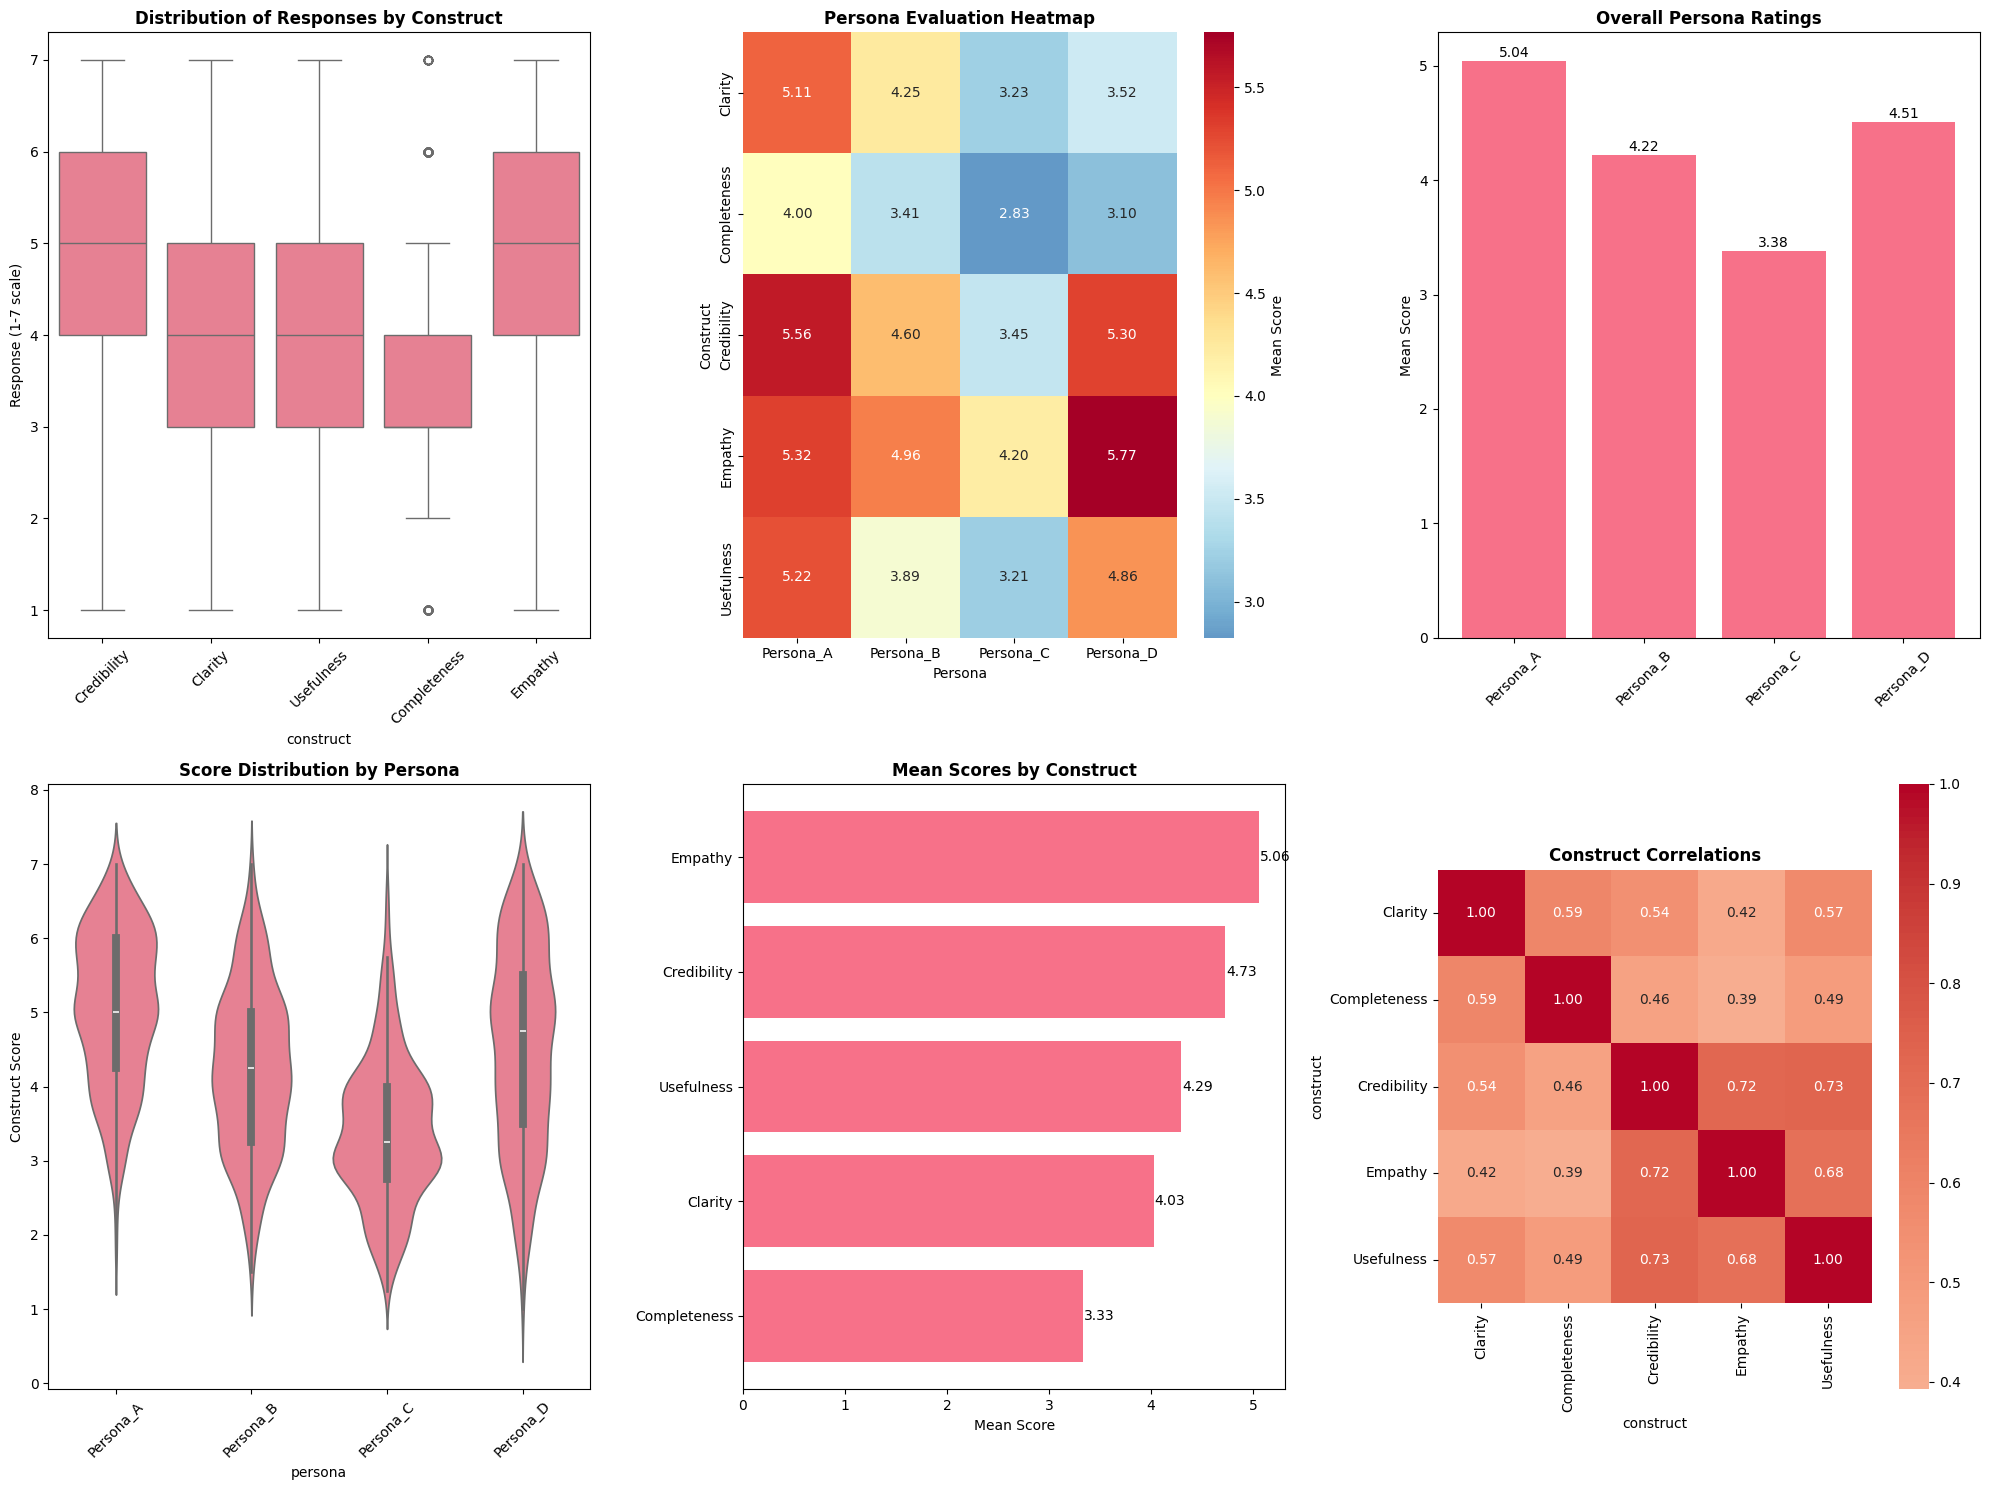


Construct Correlation Matrix:
construct     Clarity  Completeness  Credibility  Empathy  Usefulness
construct                                                            
Clarity         1.000         0.588        0.545    0.417       0.575
Completeness    0.588         1.000        0.461    0.393       0.486
Credibility     0.545         0.461        1.000    0.720       0.729
Empathy         0.417         0.393        0.720    1.000       0.682
Usefulness      0.575         0.486        0.729    0.682       1.000


In [ ]:
# 3. VISUALIZATION ANALYSIS

def create_visualizations(df, construct_scores, persona_means):
    """Create comprehensive visualizations"""

    print("="*60)
    print("VISUALIZATION ANALYSIS")
    print("="*60)

    # Set up the plotting style
    plt.style.use('default')
    sns.set_palette("husl")

    # Create a figure with multiple subplots
    fig = plt.figure(figsize=(20, 15))

    # 1. Box plot of responses by construct
    plt.subplot(2, 3, 1)
    sns.boxplot(data=df, x='construct', y='response')
    plt.title('Distribution of Responses by Construct', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45)
    plt.ylabel('Response (1-7 scale)')

    # 2. Heatmap of persona means
    plt.subplot(2, 3, 2)
    sns.heatmap(persona_means.T, annot=True, cmap='RdYlBu_r', center=4,
                fmt='.2f', cbar_kws={'label': 'Mean Score'})
    plt.title('Persona Evaluation Heatmap', fontsize=12, fontweight='bold')
    plt.xlabel('Persona')
    plt.ylabel('Construct')

    # 3. Bar plot comparing personas
    plt.subplot(2, 3, 3)
    persona_overall = construct_scores.groupby('persona')['construct_score'].mean()
    bars = plt.bar(persona_overall.index, persona_overall.values)
    plt.title('Overall Persona Ratings', fontsize=12, fontweight='bold')
    plt.ylabel('Mean Score')
    plt.xticks(rotation=45)

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.2f}', ha='center', va='bottom')

    # 4. Violin plot by persona
    plt.subplot(2, 3, 4)
    sns.violinplot(data=construct_scores, x='persona', y='construct_score')
    plt.title('Score Distribution by Persona', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45)
    plt.ylabel('Construct Score')

    # 5. Construct comparison
    plt.subplot(2, 3, 5)
    construct_means = construct_scores.groupby('construct')['construct_score'].mean().sort_values(ascending=True)
    bars = plt.barh(construct_means.index, construct_means.values)
    plt.title('Mean Scores by Construct', fontsize=12, fontweight='bold')
    plt.xlabel('Mean Score')

    # Add value labels
    for i, bar in enumerate(bars):
        width = bar.get_width()
        plt.text(width + 0.01, bar.get_y() + bar.get_height()/2.,
                f'{width:.2f}', ha='left', va='center')

    # 6. Correlation matrix
    plt.subplot(2, 3, 6)
    construct_pivot = construct_scores.pivot_table(
        index=['respondent_id', 'persona'],
        columns='construct',
        values='construct_score'
    )
    corr_matrix = construct_pivot.corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                fmt='.2f', square=True)
    plt.title('Construct Correlations', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

    return corr_matrix

corr_matrix = create_visualizations(df, construct_scores, persona_means)
print("\nConstruct Correlation Matrix:")
print(corr_matrix.round(3))

STATISTICAL SIGNIFICANCE TESTING


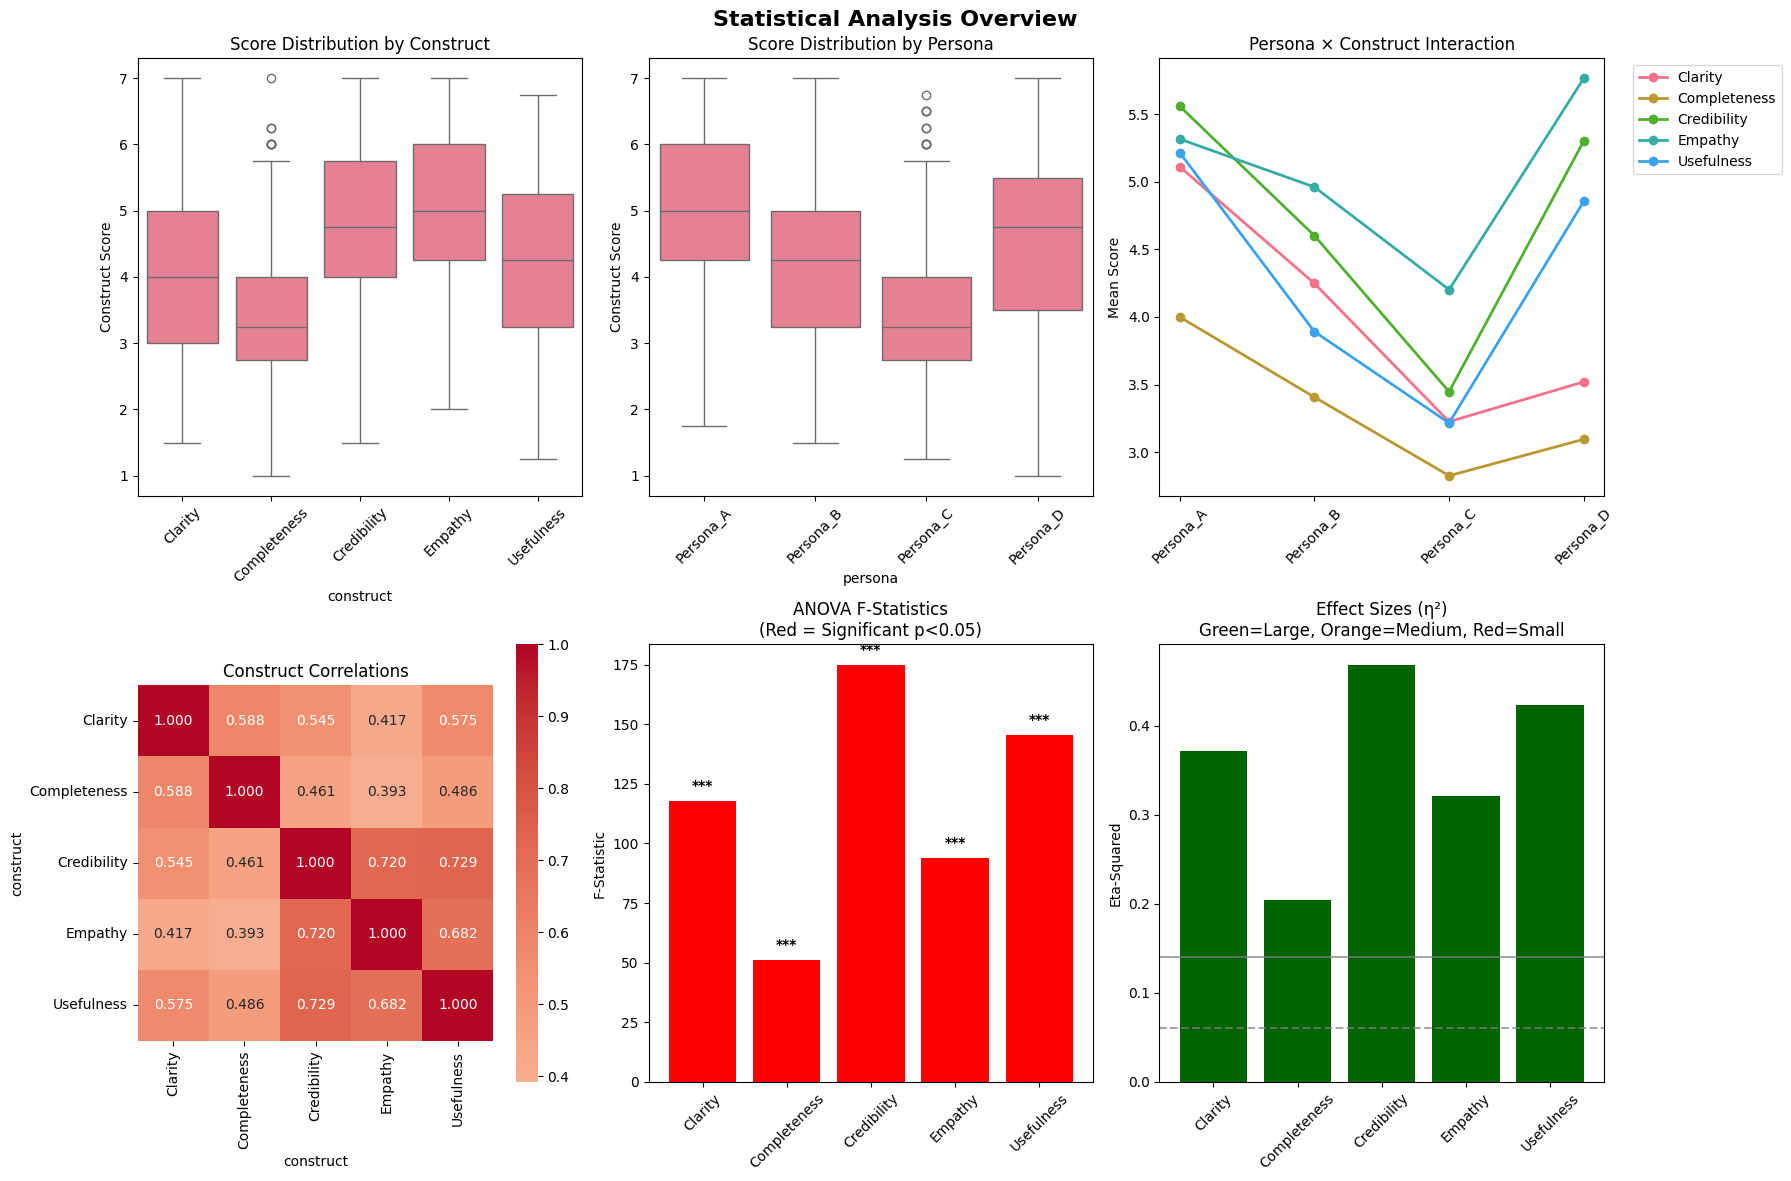


1. ONE-WAY ANOVA: Differences between Personas
--------------------------------------------------

Clarity:
  F-statistic: 117.792
  p-value: 0.0000
  Effect size (η²): 0.372
  Significance: *** (p < 0.001)
  Effect interpretation: Large effect

Completeness:
  F-statistic: 51.073
  p-value: 0.0000
  Effect size (η²): 0.205
  Significance: *** (p < 0.001)
  Effect interpretation: Large effect

Credibility:
  F-statistic: 174.777
  p-value: 0.0000
  Effect size (η²): 0.468
  Significance: *** (p < 0.001)
  Effect interpretation: Large effect

Empathy:
  F-statistic: 93.769
  p-value: 0.0000
  Effect size (η²): 0.321
  Significance: *** (p < 0.001)
  Effect interpretation: Large effect

Usefulness:
  F-statistic: 145.570
  p-value: 0.0000
  Effect size (η²): 0.423
  Significance: *** (p < 0.001)
  Effect interpretation: Large effect


2. POST-HOC PAIRWISE COMPARISONS (t-tests)
--------------------------------------------------

Clarity - Pairwise Comparisons:
  Persona_A vs Persona_B: t

In [ ]:
# 4. STATISTICAL TESTING WITH VISUALIZATIONS

def perform_statistical_tests(construct_scores):
    """Perform statistical significance tests with supporting visualizations"""

    print("="*60)
    print("STATISTICAL SIGNIFICANCE TESTING")
    print("="*60)

    # Create visualizations first
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Statistical Analysis Overview', fontsize=16, fontweight='bold')

    # 1. Box plots by construct (top left)
    ax1 = axes[0, 0]
    sns.boxplot(data=construct_scores, x='construct', y='construct_score', ax=ax1)
    ax1.set_title('Score Distribution by Construct')
    ax1.tick_params(axis='x', rotation=45)
    ax1.set_ylabel('Construct Score')

    # 2. Box plots by persona (top middle)
    ax2 = axes[0, 1]
    sns.boxplot(data=construct_scores, x='persona', y='construct_score', ax=ax2)
    ax2.set_title('Score Distribution by Persona')
    ax2.tick_params(axis='x', rotation=45)
    ax2.set_ylabel('Construct Score')

    # 3. Interaction plot (top right)
    ax3 = axes[0, 2]
    persona_construct_means = construct_scores.groupby(['persona', 'construct'])['construct_score'].mean().unstack()
    for construct in persona_construct_means.columns:
        ax3.plot(persona_construct_means.index, persona_construct_means[construct],
                marker='o', label=construct, linewidth=2)
    ax3.set_title('Persona × Construct Interaction')
    ax3.set_ylabel('Mean Score')
    ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax3.tick_params(axis='x', rotation=45)

    # 4. Construct correlation heatmap (bottom left)
    ax4 = axes[1, 0]
    construct_pivot = construct_scores.pivot_table(
        index=['respondent_id', 'persona'],
        columns='construct',
        values='construct_score'
    )
    corr_matrix = construct_pivot.corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                fmt='.3f', square=True, ax=ax4)
    ax4.set_title('Construct Correlations')

    # 5. ANOVA F-statistics (bottom middle)
    ax5 = axes[1, 1]
    f_stats = []
    p_values = []
    construct_names = []

    for construct in construct_scores['construct'].unique():
        construct_data = construct_scores[construct_scores['construct'] == construct]
        groups = []
        for persona in construct_data['persona'].unique():
            persona_scores = construct_data[construct_data['persona'] == persona]['construct_score']
            groups.append(persona_scores)

        f_stat, p_value = stats.f_oneway(*groups)
        f_stats.append(f_stat)
        p_values.append(p_value)
        construct_names.append(construct)

    colors = ['red' if p < 0.05 else 'lightblue' for p in p_values]
    bars = ax5.bar(construct_names, f_stats, color=colors)
    ax5.set_title('ANOVA F-Statistics\n(Red = Significant p<0.05)')
    ax5.set_ylabel('F-Statistic')
    ax5.tick_params(axis='x', rotation=45)

    # Add significance annotations
    for i, (bar, p_val) in enumerate(zip(bars, p_values)):
        height = bar.get_height()
        if p_val < 0.001:
            sig_text = '***'
        elif p_val < 0.01:
            sig_text = '**'
        elif p_val < 0.05:
            sig_text = '*'
        else:
            sig_text = 'ns'

        ax5.text(bar.get_x() + bar.get_width()/2., height + max(f_stats)*0.02,
                sig_text, ha='center', va='bottom', fontweight='bold')

    # 6. Effect sizes (bottom right)
    ax6 = axes[1, 2]

    # Calculate effect sizes (eta-squared) for each construct
    eta_squared = []
    for i, construct in enumerate(construct_names):
        construct_data = construct_scores[construct_scores['construct'] == construct]

        # Calculate eta-squared manually
        overall_mean = construct_data['construct_score'].mean()
        total_ss = sum((construct_data['construct_score'] - overall_mean) ** 2)

        between_ss = 0
        for persona in construct_data['persona'].unique():
            persona_data = construct_data[construct_data['persona'] == persona]
            persona_mean = persona_data['construct_score'].mean()
            n_persona = len(persona_data)
            between_ss += n_persona * (persona_mean - overall_mean) ** 2

        eta_sq = between_ss / total_ss if total_ss > 0 else 0
        eta_squared.append(eta_sq)

    colors = ['darkgreen' if eta >= 0.14 else 'orange' if eta >= 0.06 else 'lightcoral'
              for eta in eta_squared]
    bars = ax6.bar(construct_names, eta_squared, color=colors)
    ax6.set_title('Effect Sizes (η²)\nGreen=Large, Orange=Medium, Red=Small')
    ax6.set_ylabel('Eta-Squared')
    ax6.tick_params(axis='x', rotation=45)
    ax6.axhline(y=0.06, color='gray', linestyle='--', alpha=0.7, label='Medium Effect')
    ax6.axhline(y=0.14, color='gray', linestyle='-', alpha=0.7, label='Large Effect')

    plt.tight_layout()
    plt.show()

    # Now print the statistical results
    print("\n1. ONE-WAY ANOVA: Differences between Personas")
    print("-" * 50)

    for i, construct in enumerate(construct_names):
        print(f"\n{construct}:")
        print(f"  F-statistic: {f_stats[i]:.3f}")
        print(f"  p-value: {p_values[i]:.4f}")
        print(f"  Effect size (η²): {eta_squared[i]:.3f}")

        if p_values[i] < 0.001:
            significance = "*** (p < 0.001)"
        elif p_values[i] < 0.01:
            significance = "** (p < 0.01)"
        elif p_values[i] < 0.05:
            significance = "* (p < 0.05)"
        else:
            significance = "ns (not significant)"

        print(f"  Significance: {significance}")

        # Effect size interpretation
        if eta_squared[i] >= 0.14:
            effect_interp = "Large effect"
        elif eta_squared[i] >= 0.06:
            effect_interp = "Medium effect"
        elif eta_squared[i] >= 0.01:
            effect_interp = "Small effect"
        else:
            effect_interp = "Negligible effect"

        print(f"  Effect interpretation: {effect_interp}")

    # 2. Post-hoc pairwise comparisons for significant results
    print("\n\n2. POST-HOC PAIRWISE COMPARISONS (t-tests)")
    print("-" * 50)

    from itertools import combinations

    personas = construct_scores['persona'].unique()
    persona_pairs = list(combinations(personas, 2))

    for i, construct in enumerate(construct_names):
        if p_values[i] < 0.05:  # Only show post-hoc for significant ANOVAs
            construct_data = construct_scores[construct_scores['construct'] == construct]

            print(f"\n{construct} - Pairwise Comparisons:")

            for persona1, persona2 in persona_pairs:
                group1 = construct_data[construct_data['persona'] == persona1]['construct_score']
                group2 = construct_data[construct_data['persona'] == persona2]['construct_score']

                t_stat, p_value = stats.ttest_ind(group1, group2)

                mean_diff = group1.mean() - group2.mean()

                # Calculate Cohen's d for effect size
                pooled_std = np.sqrt(((len(group1) - 1) * group1.var() +
                                    (len(group2) - 1) * group2.var()) /
                                   (len(group1) + len(group2) - 2))
                cohens_d = mean_diff / pooled_std if pooled_std > 0 else 0

                if p_value < 0.05:
                    significance = "*"
                else:
                    significance = ""

                print(f"  {persona1} vs {persona2}: t={t_stat:.3f}, p={p_value:.4f}{significance}, "
                      f"diff={mean_diff:.3f}, d={cohens_d:.3f}")

    # 3. Correlation significance tests
    print("\n\n3. CONSTRUCT CORRELATION SIGNIFICANCE")
    print("-" * 50)

    constructs = construct_pivot.columns

    for i, construct1 in enumerate(constructs):
        for construct2 in constructs[i+1:]:
            corr_coef, p_value = stats.pearsonr(
                construct_pivot[construct1].dropna(),
                construct_pivot[construct2].dropna()
            )

            if p_value < 0.001:
                significance = "***"
            elif p_value < 0.01:
                significance = "**"
            elif p_value < 0.05:
                significance = "*"
            else:
                significance = ""

            # Correlation magnitude interpretation
            abs_corr = abs(corr_coef)
            if abs_corr >= 0.7:
                corr_interp = "Strong"
            elif abs_corr >= 0.3:
                corr_interp = "Moderate"
            elif abs_corr >= 0.1:
                corr_interp = "Weak"
            else:
                corr_interp = "Negligible"

            print(f"{construct1} - {construct2}: r={corr_coef:.3f}, p={p_value:.4f}{significance} ({corr_interp})")

    return {
        'f_statistics': dict(zip(construct_names, f_stats)),
        'p_values': dict(zip(construct_names, p_values)),
        'effect_sizes': dict(zip(construct_names, eta_squared)),
        'correlation_matrix': corr_matrix
    }

# Run the enhanced statistical testing
statistical_results = perform_statistical_tests(construct_scores)

In [ ]:
# 5. COMPREHENSIVE SUMMARY REPORT

def generate_summary_report(df, construct_scores, persona_means, reliability_results):
    """Generate a comprehensive summary report"""

    print("="*80)
    print("PERSONA PERCEPTION ANALYSIS - EXECUTIVE SUMMARY")
    print("="*80)

    # Basic statistics
    n_respondents = df['respondent_id'].nunique()
    n_personas = df['persona'].nunique()
    n_constructs = df['construct'].nunique()
    n_total_responses = len(df)

    print(f"\nSTUDY OVERVIEW:")
    print(f"• Total Respondents: {n_respondents}")
    print(f"• Personas Evaluated: {n_personas}")
    print(f"• Evaluation Constructs: {n_constructs}")
    print(f"• Total Responses: {n_total_responses}")
    print(f"• Response Scale: 1-7 Likert scale")

    # Overall findings
    overall_mean = construct_scores['construct_score'].mean()
    overall_std = construct_scores['construct_score'].std()

    print(f"\nOVERALL FINDINGS:")
    print(f"• Overall Mean Score: {overall_mean:.2f} ± {overall_std:.2f}")
    print(f"• Score Range: {construct_scores['construct_score'].min():.2f} - {construct_scores['construct_score'].max():.2f}")

    # Best and worst performing personas
    persona_overall = construct_scores.groupby('persona')['construct_score'].mean().sort_values(ascending=False)

    print(f"\nPERSONA RANKINGS:")
    for i, (persona, score) in enumerate(persona_overall.items(), 1):
        print(f"  {i}. {persona}: {score:.2f}")

    # Construct performance
    construct_overall = construct_scores.groupby('construct')['construct_score'].mean().sort_values(ascending=False)

    print(f"\nCONSTRUCT PERFORMANCE:")
    for construct, score in construct_overall.items():
        print(f"  {construct}: {score:.2f}")

    # Reliability summary
    print(f"\nRELIABILITY ASSESSMENT:")
    avg_alpha = np.mean([r['cronbach_alpha'] for r in reliability_results.values() if not np.isnan(r['cronbach_alpha'])])
    print(f"• Average Cronbach's Alpha: {avg_alpha:.3f}")

    reliable_constructs = [k for k, v in reliability_results.items() if v['cronbach_alpha'] >= 0.7]
    print(f"• Reliable Constructs (α ≥ 0.7): {len(reliable_constructs)}/{len(reliability_results)}")

    if reliable_constructs:
        print(f"  - {', '.join(reliable_constructs)}")

    # Key insights
    print(f"\nKEY INSIGHTS:")

    # Identify best persona
    best_persona = persona_overall.index[0]
    best_score = persona_overall.iloc[0]
    print(f"• {best_persona} is the highest-rated persona (M = {best_score:.2f})")

    # Identify strongest construct
    best_construct = construct_overall.index[0]
    best_construct_score = construct_overall.iloc[0]
    print(f"• {best_construct} is the strongest evaluation dimension (M = {best_construct_score:.2f})")

    # Identify areas for improvement
    worst_construct = construct_overall.index[-1]
    worst_construct_score = construct_overall.iloc[-1]
    print(f"• {worst_construct} shows room for improvement (M = {worst_construct_score:.2f})")

    # Statistical significance
    print(f"\nSTATISTICAL NOTES:")
    print(f"• Perform ANOVA to test for significant differences between personas")
    print(f"• Use post-hoc tests for pairwise comparisons when ANOVA is significant")
    print(f"• Consider effect sizes (Cohen's d) in addition to p-values")
    print(f"• Validate findings with additional data collection if needed")

    print("\n" + "="*80)

generate_summary_report(df, construct_scores, persona_means, reliability_results)

# Save data for further analysis
print("\nSaving data for further analysis...")
df.to_csv('persona_perception_responses.csv', index=False)
construct_scores.to_csv('persona_construct_scores.csv', index=False)
persona_means.to_csv('persona_means_by_construct.csv')

print("Analysis complete! Data saved to CSV files.")
print("\nFiles created:")
print("• persona_perception_responses.csv - Raw response data")
print("• persona_construct_scores.csv - Aggregated construct scores")
print("• persona_means_by_construct.csv - Mean scores by persona and construct")

PERSONA PERCEPTION ANALYSIS - EXECUTIVE SUMMARY

STUDY OVERVIEW:
• Total Respondents: 150
• Personas Evaluated: 4
• Evaluation Constructs: 5
• Total Responses: 12000
• Response Scale: 1-7 Likert scale

OVERALL FINDINGS:
• Overall Mean Score: 4.29 ± 1.27
• Score Range: 1.00 - 7.00

PERSONA RANKINGS:
  1. Persona_A: 5.04
  2. Persona_D: 4.51
  3. Persona_B: 4.22
  4. Persona_C: 3.38

CONSTRUCT PERFORMANCE:
  Empathy: 5.06
  Credibility: 4.73
  Usefulness: 4.29
  Clarity: 4.03
  Completeness: 3.33

RELIABILITY ASSESSMENT:
• Average Cronbach's Alpha: 0.905
• Reliable Constructs (α ≥ 0.7): 5/5
  - Credibility, Clarity, Usefulness, Completeness, Empathy

KEY INSIGHTS:
• Persona_A is the highest-rated persona (M = 5.04)
• Empathy is the strongest evaluation dimension (M = 5.06)
• Completeness shows room for improvement (M = 3.33)

STATISTICAL NOTES:
• Perform ANOVA to test for significant differences between personas
• Use post-hoc tests for pairwise comparisons when ANOVA is significant
• Co